<a href="https://colab.research.google.com/github/Lasal0425/Machine-Learning-Tutorials/blob/main/Tute10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow

In [ ]:
import numpy as np
import tensorflow
from  tensorflow.keras.layers import Conv2D, Activation, MaxPooling2D, Dense, Flatten
from tensorflow.keras import Sequential

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
X_train = np.loadtxt('/content/drive/MyDrive/Colab Notebooks/Tutorial 10/input.csv', delimiter=',')
Y_train = np.loadtxt('/content/drive/MyDrive/Colab Notebooks/Tutorial 10/labels.csv', delimiter=',')

X_test = np.loadtxt('/content/drive/MyDrive/Colab Notebooks/Tutorial 10/input_test.csv',delimiter=',')
Y_test = np.loadtxt('/content/drive/MyDrive/Colab Notebooks/Tutorial 10/labels_test.csv',delimiter=',')

In [ ]:
print("Shape of X_train: ", X_train.shape)
print("Shape of Y_train: ", Y_train.shape)
print("Shape of X_test: ", X_test.shape)
print("Shape of Y_test: ", Y_test.shape)

Shape of X_train:  (2000, 30000)
Shape of Y_train:  (2000,)
Shape of X_test:  (400, 30000)
Shape of Y_test:  (400,)


In [ ]:
X_train = X_train.reshape(len(X_train),100,100,3)
Y_train = Y_train.reshape(len(Y_train),1)

X_test = X_test.reshape(len(X_test),100,100,3)
Y_test = Y_test.reshape(len(Y_test),1)

In [ ]:
print("Shape of X_train: ", X_train.shape)
print("Shape of Y_train: ", Y_train.shape)
print("Shape of X_test: ", X_test.shape)
print("Shape of Y_test: ", Y_test.shape)

Shape of X_train:  (2000, 100, 100, 3)
Shape of Y_train:  (2000, 1)
Shape of X_test:  (400, 100, 100, 3)
Shape of Y_test:  (400, 1)


In [ ]:
X_train[1,:]

array([[[131., 128., 135.],
        [160., 157., 164.],
        [198., 192., 204.],
        ...,
        [250., 249., 247.],
        [255., 255., 253.],
        [250., 249., 245.]],

       [[140., 137., 144.],
        [127., 124., 131.],
        [120., 114., 124.],
        ...,
        [251., 253., 252.],
        [254., 255., 253.],
        [254., 255., 251.]],

       [[204., 202., 207.],
        [187., 185., 190.],
        [147., 142., 148.],
        ...,
        [249., 255., 255.],
        [238., 247., 242.],
        [232., 241., 236.]],

       ...,

       [[174., 182., 195.],
        [172., 180., 193.],
        [178., 186., 197.],
        ...,
        [ 87., 114.,  97.],
        [ 75.,  99.,  83.],
        [ 80., 105.,  86.]],

       [[166., 173., 189.],
        [164., 172., 185.],
        [172., 180., 193.],
        ...,
        [ 78., 106.,  84.],
        [ 72.,  97.,  76.],
        [ 77., 102.,  81.]],

       [[173., 180., 196.],
        [172., 179., 195.],
        [174., 1

In [ ]:
X_train = X_train/255.0
X_test = X_test/255.0

In [ ]:
X_train[1,:]

array([[[0.51372549, 0.50196078, 0.52941176],
        [0.62745098, 0.61568627, 0.64313725],
        [0.77647059, 0.75294118, 0.8       ],
        ...,
        [0.98039216, 0.97647059, 0.96862745],
        [1.        , 1.        , 0.99215686],
        [0.98039216, 0.97647059, 0.96078431]],

       [[0.54901961, 0.5372549 , 0.56470588],
        [0.49803922, 0.48627451, 0.51372549],
        [0.47058824, 0.44705882, 0.48627451],
        ...,
        [0.98431373, 0.99215686, 0.98823529],
        [0.99607843, 1.        , 0.99215686],
        [0.99607843, 1.        , 0.98431373]],

       [[0.8       , 0.79215686, 0.81176471],
        [0.73333333, 0.7254902 , 0.74509804],
        [0.57647059, 0.55686275, 0.58039216],
        ...,
        [0.97647059, 1.        , 1.        ],
        [0.93333333, 0.96862745, 0.94901961],
        [0.90980392, 0.94509804, 0.9254902 ]],

       ...,

       [[0.68235294, 0.71372549, 0.76470588],
        [0.6745098 , 0.70588235, 0.75686275],
        [0.69803922, 0

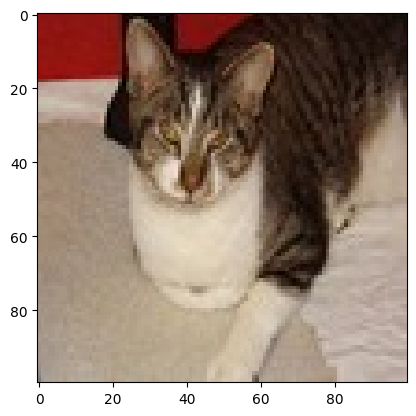

In [ ]:
import matplotlib.pyplot as plt
import random
idx= random.randint(0,len(X_train))
plt.imshow(X_train[idx,:])

In [ ]:
model = Sequential([
    Conv2D(32,(3,3),activation = 'relu',input_shape=(100,100,3)),
    MaxPooling2D((2,2)),
    Conv2D(32,(3,3),activation = 'relu'),
    MaxPooling2D((2,2)),
    Flatten(),
#The above layers are for feature extraction
#The following layers are for modelling (learning) with one hidden layer and a final output layer with a sigmoid activation function.
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model = Sequential()

model.add (Conv2D(32,(3,3),activation = 'relu',input_shape=(100,100,3)))
model.add(MaxPooling2D((2,2)))
model.add( Conv2D(32,(3,3),activation = 'relu'))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
#The above layers are for feature extraction
#The following layers are for modelling (learning) with one hidden layer with ReLU AF, and a final output layer with a sigmoid activation function.
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))



In [ ]:
model.compile(loss = 'binary_crossentropy' , optimizer ='adam', metrics=['accuracy'])

In [ ]:
model.fit(X_train, Y_train, epochs = 5, batch_size = 64)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 655ms/step - accuracy: 0.5121 - loss: 0.7860
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 40s 654ms/step - accuracy: 0.5825 - loss: 0.6811
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 41s 661ms/step - accuracy: 0.6632 - loss: 0.6370
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 41s 653ms/step - accuracy: 0.7047 - loss: 0.5892
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 22s 683ms/step - accuracy: 0.7071 - loss: 0.5693


In [ ]:
model.evaluate( X_test, Y_test, batch_size = 40, verbose=0)

[0.8484129905700684, 0.5849999785423279]

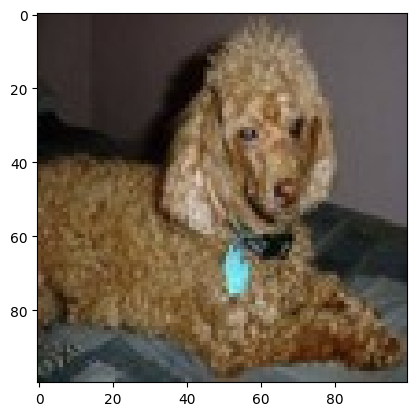

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
[[0.10407052]]


In [ ]:
idx2 = random.randint (0,len(Y_test))
plt.imshow(X_test[idx2,:])
plt.show()

y_pred = model.predict(X_test[idx2,:].reshape(1,100,100,3))
print(y_pred)

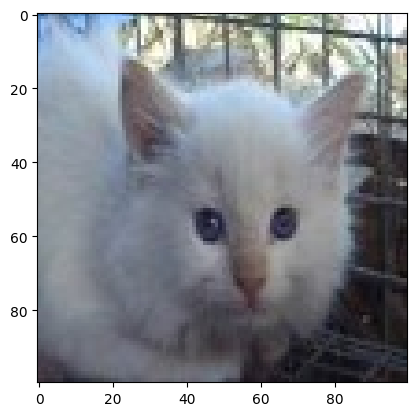

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
The model prediction is a  Dog


In [ ]:
# If you want the model to actually produce a prediction of Cat or Dog output
idx2 = random.randint (0,len(Y_test))
plt.imshow(X_test[idx2,:])
plt.show()
y_pred = model.predict(X_test[idx2,:].reshape(1,100,100,3))
if (y_pred > 0.5):
  pred = 'Cat'
else:
  pred = 'Dog'
print("The model prediction is a ", pred)